In [ ]:
import sys
!{sys.executable} -m pip install momentfm
import sys, os
sys.path.append(os.path.abspath(".."))  # go one level upimport numpy as np

import pandas as pd
import matplotlib.pyplot as plt
import torch
import numpy as np
import os
import logging
from pathlib import Path
from momentfm import MOMENTPipeline
import scipy
from sklearn.decomposition import PCA
from moment import load_mean_activations
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from clustering.moment import  get_activations_MOMENT
from clustering.utils import load_dataset
from clustering.plotting import plot_knn_3d, plot_knn
#from hough_scripts.separability import embeddings_pca_corr, lda_pca_embeddings, embeddings_umap


In [ ]:
def compute_knn(activations, n_components):
    
    '''activation - np.array of shape (n_transfer, n_samples, 1024)
       n_components - int PCA dimension
       computes knn on embeddings after PCA reduction'''
    
    n_transform = activations.shape[0]
    n_samples = activations.shape[1]
    
    combined = activations.reshape(-1, activations.shape[-1])
    reducer = PCA(n_components=n_components)

    combined_reduced = reducer.fit_transform(combined)
    reduced_list = []
    
    for i in range(n_transform):
        reduced_list.append(combined_reduced[n_samples*i:n_samples*(i+1)])
    print(reduced_list[0].shape)
    
    X = np.vstack(reduced_list)
    l = []
    for i in range(n_transform):
        l += [i] * n_samples
    y = np.array(l)

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    knn = KNeighborsClassifier(n_neighbors=3)
    knn.fit(X_train, y_train)

    y_pred = knn.predict(X_test)


    print("n_components:"+ str(n_components))
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("\nClassification Report:\n", classification_report(y_test, y_pred))
    print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
    
    return X_test, y_test, y_pred


In [ ]:
# Load activations, shape will be: (n_transform, num_samples, dimension)

path = "/zfsauton2/home/ekaczmar/representations-in-tsfms-main/representations-in-tsfms-main/clustering/activations/"
activations_exps = np.load(os.path.join(path,'activations_exps.npy'))
activations_sines = np.load(os.path.join(path,'activations_sines.npy'))
activations_trends = np.load(os.path.join(path,'activations_trends.npy'))

n_transform = activations_exps.shape[0]



'activations_exps = np.stack([\n    load_mean_activations(os.path.join(path, f"exp_dense{ind+1}.parquet"), model_type, num_samples, device)\n    for ind in range(n_transform)\n])\n\nnp.save(os.path.join(path_save,\'activations_exps_dense.npy\'), activations_exps)'

In [ ]:
#Compute knn classification

n_components = 5 #,5,10,50,100]
X_test_t, y_test_t, y_pred_t = compute_knn(activations_trends, n_components)
X_test_e, y_test_e, y_pred_e = compute_knn(activations_exps, n_components)
#X_test_s, y_test_s, y_pred_s = compute_knn(activations_sines, n_components)


(100, 5)
n_components:5
Accuracy: 1.0

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        20
           1       1.00      1.00      1.00        20
           2       1.00      1.00      1.00        20
           3       1.00      1.00      1.00        20
           4       1.00      1.00      1.00        20
           5       1.00      1.00      1.00        20
           6       1.00      1.00      1.00        20
           7       1.00      1.00      1.00        20
           8       1.00      1.00      1.00        20
           9       1.00      1.00      1.00        20

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200


Confusion Matrix:
 [[20  0  0  0  0  0  0  0  0  0]
 [ 0 20  0  0  0  0  0  0  0  0]
 [ 0  0 20  0  0  0  0  0  0  0]
 [ 0  0  0 20  0  0  0  0  0  0]
 [ 0  0  0  0 20  0  0  0 

In [ ]:
plot_knn(X_test_e, y_test_e, n_transform=n_transform)

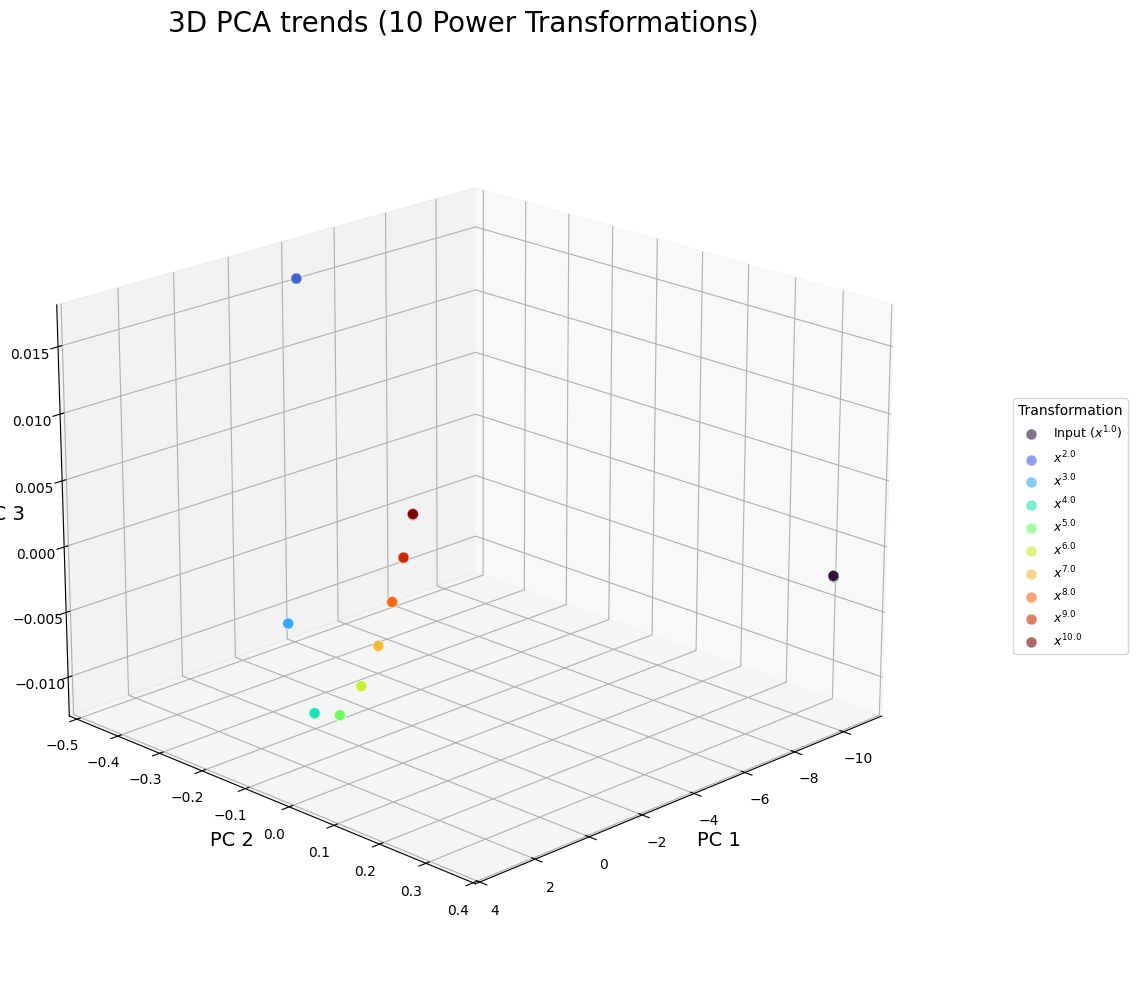

In [ ]:
plot_knn_3d(X_test_e, y_test_e, n_transform=n_transform)